In [104]:
# Import libraries and set seed
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)
np.random.seed(8)

## Read & Clean Data


In [105]:
# Read data 
menstrual = pd.read_csv('data.csv')
menstrual = menstrual.drop(columns = 'id')
menstrual.head()

,day_in_study,sedentary_mins,active_mins,glucose_mean,rhr_mean,minutes_asleep,minutes_awake,sleep_efficiency_mean,sleep_score_overall,sleep_score_revitalization,...,headaches,cramps,sorebreasts,fatigue,sleepissue,moodswing,stress,foodcravings,indigestion,bloating
0,1,753.0,64,5.498958,74.785346,1027.0,26.0,98.0,NaN,NaN,...,High,Very Low/Little,Very Low/Little,High,Low,Very Low/Little,Moderate,Very Low/Little,Very Low/Little,Very Low/Little
1,2,855.0,74,5.372222,80.407307,77.0,4.0,95.0,NaN,NaN,...,Very High,Very Low/Little,Very Low/Little,High,Very High,Very Low/Little,Moderate,Very Low/Little,Very Low/Little,Very Low/Little
2,3,751.0,159,5.579514,84.686869,502.0,28.0,95.0,NaN,NaN,...,High,Very Low/Little,Very Low/Little,Very High,Very High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little
3,4,905.0,86,5.206597,83.852219,384.0,65.0,93.0,80.0,22.0,...,Very Low/Little,Very Low/Little,Very Low/Little,High,Very High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little
4,5,1430.0,10,5.381597,0.000000,NaN,NaN,NaN,NaN,NaN,...,Very Low/Little,Very Low/Little,Very Low/Little,High,High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little


In [106]:
mlp_data = menstrual[['active_mins', 'glucose_mean', 'rhr_mean', 'sleep_score_overall', 'phase', 'lh', 'estrogen', 'sleep_efficiency_mean', 'headaches', 'cramps', 'sorebreasts', 'fatigue', 'sleepissue', 'moodswing', 'stress', 'foodcravings', 'indigestion', 'bloating']]
mlp_data.head()

,active_mins,glucose_mean,rhr_mean,sleep_score_overall,phase,lh,estrogen,sleep_efficiency_mean,headaches,cramps,sorebreasts,fatigue,sleepissue,moodswing,stress,foodcravings,indigestion,bloating
0,64,5.498958,74.785346,NaN,Follicular,2.9,94.2,98.0,High,Very Low/Little,Very Low/Little,High,Low,Very Low/Little,Moderate,Very Low/Little,Very Low/Little,Very Low/Little
1,74,5.372222,80.407307,NaN,Follicular,1.2,226.3,95.0,Very High,Very Low/Little,Very Low/Little,High,Very High,Very Low/Little,Moderate,Very Low/Little,Very Low/Little,Very Low/Little
2,159,5.579514,84.686869,NaN,Follicular,3.5,276.8,95.0,High,Very Low/Little,Very Low/Little,Very High,Very High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little
3,86,5.206597,83.852219,80.0,Fertility,1.8,322.1,93.0,Very Low/Little,Very Low/Little,Very Low/Little,High,Very High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little
4,10,5.381597,0.000000,NaN,Fertility,4.6,244.9,NaN,Very Low/Little,Very Low/Little,Very Low/Little,High,High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little


In [107]:
targets = ['headaches', 'cramps', 'sorebreasts', 'fatigue', 'sleepissue', 'moodswing', 'stress', 'foodcravings', 'indigestion', 'bloating']
mlp_bin = mlp_data.copy()
for col in targets:
    mlp_bin[f'bin_{col}'] = (mlp_data[col] != 'Not at all').astype(int)

mlp_bin = mlp_bin.drop(columns=targets)
mlp_bin.head()

,active_mins,glucose_mean,rhr_mean,sleep_score_overall,phase,lh,estrogen,sleep_efficiency_mean,bin_headaches,bin_cramps,bin_sorebreasts,bin_fatigue,bin_sleepissue,bin_moodswing,bin_stress,bin_foodcravings,bin_indigestion,bin_bloating
0,64,5.498958,74.785346,NaN,Follicular,2.9,94.2,98.0,1,1,1,1,1,1,1,1,1,1
1,74,5.372222,80.407307,NaN,Follicular,1.2,226.3,95.0,1,1,1,1,1,1,1,1,1,1
2,159,5.579514,84.686869,NaN,Follicular,3.5,276.8,95.0,1,1,1,1,1,1,1,1,1,1
3,86,5.206597,83.852219,80.0,Fertility,1.8,322.1,93.0,1,1,1,1,1,1,1,1,1,1
4,10,5.381597,0.000000,NaN,Fertility,4.6,244.9,NaN,1,1,1,1,1,1,1,1,1,1


In [108]:
mlp_onehot = pd.get_dummies(mlp_bin, drop_first = True, dtype = int)
mlp_onehot.head()

,active_mins,glucose_mean,rhr_mean,sleep_score_overall,lh,estrogen,sleep_efficiency_mean,bin_headaches,bin_cramps,bin_sorebreasts,bin_fatigue,bin_sleepissue,bin_moodswing,bin_stress,bin_foodcravings,bin_indigestion,bin_bloating,phase_Follicular,phase_Luteal,phase_Menstrual
0,64,5.498958,74.785346,NaN,2.9,94.2,98.0,1,1,1,1,1,1,1,1,1,1,1,0,0
1,74,5.372222,80.407307,NaN,1.2,226.3,95.0,1,1,1,1,1,1,1,1,1,1,1,0,0
2,159,5.579514,84.686869,NaN,3.5,276.8,95.0,1,1,1,1,1,1,1,1,1,1,1,0,0
3,86,5.206597,83.852219,80.0,1.8,322.1,93.0,1,1,1,1,1,1,1,1,1,1,0,0,0
4,10,5.381597,0.000000,NaN,4.6,244.9,NaN,1,1,1,1,1,1,1,1,1,1,0,0,0


In [109]:
print(mlp_onehot.isna().sum())

active_mins                0
glucose_mean             590
rhr_mean                   0
sleep_score_overall      450
lh                       223
estrogen                 224
sleep_efficiency_mean    526
bin_headaches              0
bin_cramps                 0
bin_sorebreasts            0
bin_fatigue                0
bin_sleepissue             0
bin_moodswing              0
bin_stress                 0
bin_foodcravings           0
bin_indigestion            0
bin_bloating               0
phase_Follicular           0
phase_Luteal               0
phase_Menstrual            0
dtype: int64


In [110]:
# Impute missing features with mean
mlp_onehot['glucose_mean'] = mlp_onehot['glucose_mean'].fillna(mlp_onehot['glucose_mean'].mean())
mlp_onehot['sleep_score_overall'] = mlp_onehot['sleep_score_overall'].fillna(mlp_onehot['glucose_mean'].mean())
mlp_onehot['lh'] = mlp_onehot['lh'].fillna(mlp_onehot['lh'].mean())
mlp_onehot['estrogen'] = mlp_onehot['estrogen'].fillna(mlp_onehot['estrogen'].mean())
mlp_onehot['sleep_efficiency_mean'] = mlp_onehot['sleep_efficiency_mean'].fillna(mlp_onehot['sleep_efficiency_mean'].mean())

print(mlp_onehot.isna().sum())

active_mins              0
glucose_mean             0
rhr_mean                 0
sleep_score_overall      0
lh                       0
estrogen                 0
sleep_efficiency_mean    0
bin_headaches            0
bin_cramps               0
bin_sorebreasts          0
bin_fatigue              0
bin_sleepissue           0
bin_moodswing            0
bin_stress               0
bin_foodcravings         0
bin_indigestion          0
bin_bloating             0
phase_Follicular         0
phase_Luteal             0
phase_Menstrual          0
dtype: int64


In [111]:
target_cols = [col for col in mlp_onehot.columns if 'bin' in col]
for col in target_cols:
    mlp_onehot[col] = mlp_onehot.pop(col)

mlp_onehot.head()

,active_mins,glucose_mean,rhr_mean,sleep_score_overall,lh,estrogen,sleep_efficiency_mean,phase_Follicular,phase_Luteal,phase_Menstrual,bin_headaches,bin_cramps,bin_sorebreasts,bin_fatigue,bin_sleepissue,bin_moodswing,bin_stress,bin_foodcravings,bin_indigestion,bin_bloating
0,64,5.498958,74.785346,11.406948,2.9,94.2,98.000000,1,0,0,1,1,1,1,1,1,1,1,1,1
1,74,5.372222,80.407307,11.406948,1.2,226.3,95.000000,1,0,0,1,1,1,1,1,1,1,1,1,1
2,159,5.579514,84.686869,11.406948,3.5,276.8,95.000000,1,0,0,1,1,1,1,1,1,1,1,1,1
3,86,5.206597,83.852219,80.000000,1.8,322.1,93.000000,0,0,0,1,1,1,1,1,1,1,1,1,1
4,10,5.381597,0.000000,11.406948,4.6,244.9,92.455916,0,0,0,1,1,1,1,1,1,1,1,1,1


In [112]:
# Check how many symptoms each individual has and check proportions in dataset
mlp_onehot['total_symptoms'] = mlp_onehot[target_cols].sum(axis=1)
all_symptoms  = mlp_onehot[mlp_onehot['total_symptoms'] == 10]
some_symptoms = mlp_onehot[(mlp_onehot['total_symptoms'] >= 5) & (mlp_onehot['total_symptoms'] < 10)]
few_symptoms  = mlp_onehot[mlp_onehot['total_symptoms'] < 5]

print("Dataset Size:", len(mlp_onehot))
print("Proportion of Individuals With All Symptoms:", len(all_symptoms) / len(mlp_onehot))
print("Proportion of Individuals With 5-9 symptoms:", len(some_symptoms) / len(mlp_onehot))
print("Proportion of Individuals With 0-4 symptoms:", len(few_symptoms) / len(mlp_onehot))

Dataset Size: 3698
Proportion of Individuals With All Symptoms: 0.45429962141698216
Proportion of Individuals With 5-9 symptoms: 0.32936722552731207
Proportion of Individuals With 0-4 symptoms: 0.21633315305570577


In [113]:
# Randomly sample from individuals that have all 10 symptoms to balance dataset
all_symptoms_sampled = all_symptoms.sample(frac = 0.6, random_state = 42)
mlp_sampled = pd.concat([all_symptoms_sampled, some_symptoms, few_symptoms])
mlp_sampled = mlp_sampled.drop(columns='total_symptoms')

print("Sampled dataset size:", len(mlp_sampled))
print("All symptoms:", len(all_symptoms_sampled) / len(mlp_sampled))
print("5-9 symptoms:", len(some_symptoms) / len(mlp_sampled))
print("0-4 symptoms:", len(few_symptoms) / len(mlp_sampled))
print("Mean for Each Symptom to Evaluate Skew Towards Having The Symptom")
print(mlp_sampled[target_cols].mean())

Sampled dataset size: 3026
All symptoms: 0.3331130204890945
5-9 symptoms: 0.40251156642432256
0-4 symptoms: 0.26437541308658297
Mean for Each Symptom to Evaluate Skew Towards Having The Symptom
bin_headaches       0.640449
bin_cramps          0.479180
bin_sorebreasts     0.432254
bin_fatigue         0.853272
bin_sleepissue      0.781229
bin_moodswing       0.658956
bin_stress          0.855915
bin_foodcravings    0.695307
bin_indigestion     0.609055
bin_bloating        0.638467
dtype: float64


## Prep Data for MLP


In [114]:
# Convert data to array
mlp_array = mlp_sampled.to_numpy()
print(mlp_array)

[[180.          11.40694841  63.48966312 ...   1.           1.
    1.        ]
 [ 25.           5.68297872  71.9159708  ...   1.           1.
    1.        ]
 [  0.         122.20138889   0.         ...   1.           1.
    1.        ]
 ...
 [ 67.           6.15972222  67.26989365 ...   0.           0.
    0.        ]
 [ 99.           7.20902778  68.66525173 ...   1.           0.
    0.        ]
 [122.           7.29298246  68.05343342 ...   1.           0.
    0.        ]]


In [115]:
# Create feature and target arrays
X = mlp_array[:, :-10]  
y = mlp_array[:, -10:]   

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3026, 10)
y shape: (3026, 10)


In [116]:
# Scale data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X).round(2)

print("X_scaled shape:", X_scaled.shape)
print("y shape:", y.shape)

X_scaled shape: (3026, 10)
y shape: (3026, 10)


In [117]:
# Add bias term
ones = np.ones((X_scaled.shape[0], 1))
Phi = np.hstack((X_scaled, ones))

print("Phi shape:", Phi.shape)

Phi shape: (3026, 11)


In [118]:
# Split data into train and test
Phi_train, Phi_test, y_train, y_test = train_test_split(Phi, y, test_size=0.3, random_state=42)

print("Phi_train:", Phi_train.shape)
print("Phi_test:", Phi_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Phi_train: (2118, 11)
Phi_test: (908, 11)
y_train: (2118, 10)
y_test: (908, 10)


In [119]:
# Inspect training set
Phi_train, y_train

(array([[0.15, 0.03, 0.7 , ..., 0.  , 1.  , 1.  ],
        [0.55, 0.06, 0.76, ..., 0.  , 0.  , 1.  ],
        [0.19, 0.03, 0.87, ..., 0.  , 1.  , 1.  ],
        ...,
        [0.2 , 0.02, 0.79, ..., 1.  , 0.  , 1.  ],
        [0.1 , 0.03, 0.72, ..., 0.  , 0.  , 1.  ],
        [0.  , 0.03, 0.  , ..., 1.  , 0.  , 1.  ]]),
 array([[0., 1., 0., ..., 1., 0., 0.],
        [1., 0., 0., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        ...,
        [0., 0., 0., ..., 1., 1., 1.],
        [1., 0., 0., ..., 1., 0., 1.],
        [1., 1., 1., ..., 1., 1., 1.]]))

## Implement MLP From Scratch Using Gradient Descent


In [120]:
# Define step size (eta), epochs, number of hidden nodes (q), W1, W2
eta = 0.1
epochs = 1000

q = 64
d = Phi_train.shape[1]     
k = y_train.shape[1]       

np.random.seed(42)
W1 = np.random.randn(d, q) * 0.1
W2 = np.random.randn(q, k) * 0.1

print("W1 shape:", W1.shape)
print("W2 shape:", W2.shape)

W1 shape: (11, 64)
W2 shape: (64, 10)


In [121]:
# Define f(x) using ReLU for h and sigmoid for output
def f(x, W1, W2):
    h = np.maximum(0, W1.T @ x)
    return 1 / (1 + np.exp(-1 * (W2.T @ h)))

In [122]:
# Run Gradient Descent
errors = []
n = Phi_train.shape[0]

for epoch in range(epochs):
    # calculate dW2
    dW2 = 0
    for i, j in enumerate(y_train):
        x = np.reshape(Phi_train[i], (d, 1))
        h = np.maximum(0, W1.T @ x)
        yhat = 1 / (1 + np.exp(-1 * (W2.T @ h)))          
        error = yhat - y_train[i].reshape(-1, 1)        

        dW2 += (1 / n) * (h @ error.T)                

    # calculate dW1
    dW1 = 0
    for i, j in enumerate(y_train):
        x = np.reshape(Phi_train[i], (d, 1))
        h = np.maximum(0, W1.T @ x)
        yhat = 1 / (1 + np.exp(-1 * (W2.T @ h)))          
        error = yhat - y_train[i].reshape(-1, 1)         

        mat1 = np.heaviside(h, 0)                       
        hidden_error = (W2 @ error) * mat1            

        dW1 += (1 / n) * (x @ hidden_error.T)           

    # update W1 & W2
    W1 = W1 - eta * dW1
    W2 = W2 - eta * dW2

    # calculate f(x) at each training value and error (log loss/summed BCE)
    f_x = []
    for i, j in enumerate(Phi_train):
        x = np.reshape(Phi_train[i], (d, 1))
        h = np.maximum(0, W1.T @ x)
        yhat = 1 / (1 + np.exp(-1 * (W2.T @ h)))
        f_x.append(yhat.flatten())

    f_x = np.array(f_x)  

    eps = 1e-8
    e = -(1 / n) * np.sum(y_train * np.log(f_x + eps) + (1 - y_train) * np.log(1 - f_x + eps))
    errors.append(e)

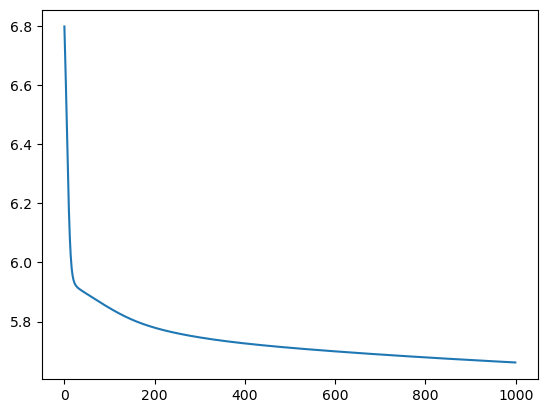

In [123]:
# Plot convergence
import matplotlib.pyplot as plt
plt.plot(range(epochs), errors, label='line')
plt.show()

In [124]:
# Print final estimates of W1 and W2
print('W1:\n', W1)
print('W2:\n', W2)

W1:
 [[ 6.44128058e-02 -1.11124035e-01  5.73351534e-02 -9.35048985e-02
  -2.36743209e-02 -2.52302480e-02  1.57921282e-01  5.38338308e-02
  -4.69474386e-02 -2.51753091e-01 -1.09975918e-01 -1.18419633e-01
   6.99533928e-03 -2.35511988e-01 -4.44839681e-01  1.58727254e-02
  -7.28503084e-02 -1.01535575e-01 -5.37495816e-01 -1.37872427e-01
   2.77549530e-01 -3.42829976e-02  6.75282047e-03 -1.44657850e-01
  -5.44865789e-02 -1.65826334e-01 -3.18019180e-01  2.62461628e-02
  -4.23545729e-02 -3.89109164e-01 -3.22636321e-01  1.88160756e-01
  -1.51158974e-02 -2.25109651e-01 -1.19382464e-01 -1.22084365e-01
   1.62095336e-01 -3.87056424e-01 -5.38588340e-01 -4.66088415e-02
   4.45962535e-02 -3.28076580e-01 -2.65364404e-02 -2.74688545e-01
  -1.48469280e-01 -7.86757980e-02 -4.25082814e-01  3.21643882e-01
   4.81920655e-02 -4.36651799e-01  5.86864521e-02 -1.09568634e-01
  -1.73988738e-01  4.92464562e-02  8.84258399e-02  5.66099901e-02
   7.85769040e-03 -3.42172931e-02  3.91167622e-01  6.04027307e-02
  -5.

In [125]:
# Predict using test data
y_pred = []
for i, j in enumerate(Phi_test):
    x = np.reshape(Phi_test[i], (d, 1))
    y_pred.append(f(x, W1, W2).flatten())

y_pred = np.array(y_pred)

print(y_pred.shape)

(908, 10)


In [126]:
# Evaluate accuracy of algorithm using log loss and accuracy + print classification report per symptom
n_test = Phi_test.shape[0]
y_pred = np.array(y_pred).reshape(n_test, 10)

eps = 1e-8
log_loss = -(1 / n_test) * np.sum((y_test * np.log(y_pred + eps)) + ((1 - y_test) * np.log(1 - y_pred + eps)))

y_pred_binary = np.round(y_pred)
matches = 0

for i in range(y_pred_binary.shape[0]):
    for j in range(y_pred_binary.shape[1]):
        if y_pred_binary[i, j] == y_test[i, j]:
            matches += 1

overall_accuracy = matches / (y_pred_binary.shape[0] * y_pred_binary.shape[1])

print('Log Loss:', log_loss)
print('Accuracy Across All Symptoms:', overall_accuracy)
print(classification_report(y_test, y_pred_binary, target_names = ['headaches','cramps',
                                                                   'sorebreasts','fatigue',
                                                                   'sleepissue','moodswing',
                                                                   'stress','foodcravings',
                                                                   'indigestion','bloating']))

Log Loss: 5.764855752751546
Accuracy Across All Symptoms: 0.7044052863436123
              precision    recall  f1-score   support

   headaches       0.66      0.95      0.78       588
      cramps       0.65      0.49      0.56       439
 sorebreasts       0.61      0.42      0.50       405
     fatigue       0.84      1.00      0.92       767
  sleepissue       0.77      0.99      0.87       698
   moodswing       0.67      0.98      0.80       589
      stress       0.86      1.00      0.92       778
foodcravings       0.71      0.99      0.83       629
 indigestion       0.63      0.99      0.77       546
    bloating       0.64      0.98      0.77       562

   micro avg       0.72      0.91      0.80      6001
   macro avg       0.70      0.88      0.77      6001
weighted avg       0.72      0.91      0.80      6001
 samples avg       0.72      0.85      0.74      6001



# Predict Symptoms for a Given Individual

In [130]:
# Set feature values for each individual and symptoms to predict
individual = {'active_mins': 15,
            'glucose_mean': 7.2,
            'rhr_mean': 92.0,
            'sleep_score_overall': 35.0,
            'lh': 1.2,
            'estrogen': 85.0,
            'sleep_efficiency_mean': 55.0,
            'phase_Follicular': 0,
            'phase_Luteal': 1,
            'phase_Menstrual': 0}

symptoms = ['Headaches', 'Cramps', 'Sore Breats', 'Fatigue', 'Sleep Issues', 'Mood Swings', 
            'Stress', 'Cravings','Indigestion', 'Bloating']

In [ ]:
# Define prediction function
def predict_given_individual(individual_features):  
    individual = pd.DataFrame([individual_features])
    individual_array = np.array(individual)
    individual_scaled = scaler.transform(individual_array)

    phi = np.hstack([individual_scaled, np.ones((1, 1))])
    x = phi.reshape(-1, 1)
    y_hat = f(x, W1, W2)
    y_pred = np.round(y_hat)

    for i in range(len(symptoms)):
        if y_pred[i] == 1:
            print(f"{symptoms[i]}: YES (Probability: {round(float(y_hat[i]), 3)})")
        else: 
            print(f"{symptoms[i]}: NO (Probability: {round(float(y_hat[i]), 3)})")

In [132]:
# Predict for given individual
predict_given_individual(individual)

Headaches: NO (Probability: 0.488)
Cramps: YES (Probability: 0.512)
Sore Breats: NO (Probability: 0.442)
Fatigue: YES (Probability: 0.797)
Sleep Issues: YES (Probability: 0.68)
Mood Swings: NO (Probability: 0.492)
Stress: YES (Probability: 0.823)
Cravings: YES (Probability: 0.612)
Indigestion: YES (Probability: 0.515)
Bloating: YES (Probability: 0.538)
